In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 


df=pd.read_csv("diabetes.csv")



In [ ]:
print(df.head())

   Feature1  Feature2  Outcome
0  2.882026  1.663770        0
1  2.200079  1.820223        0
2  2.489369  1.593427        0
3  3.120447  1.136859        0
4  2.933779  2.088713        0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Feature1  120 non-null    float64
 1   Feature2  120 non-null    float64
 2   Outcome   120 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 2.9 KB


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Feature1,120.0,5.022819,3.038153,0.723505,2.053943,5.181246,7.976594,9.191572
Feature2,120.0,5.024861,2.984773,1.136859,2.082658,4.930055,7.979243,9.129654
Outcome,120.0,0.500000,0.502096,0.000000,0.000000,0.500000,1.000000,1.000000


In [ ]:
cat_col=[col for col in df.columns 
         if df[col].dtype=='object']
print("Categorical columns:",cat_col)



Categorical columns: []


In [ ]:
df[cat_col].nunique().T

Series([], dtype: float64)

In [ ]:


print(df.duplicated().sum())
df.drop_duplicates(inplace=True)


0


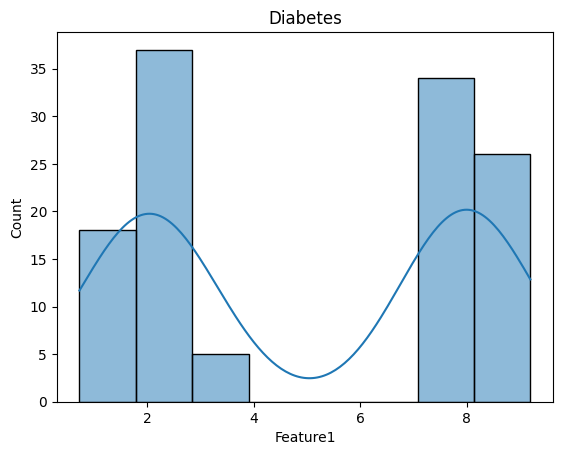

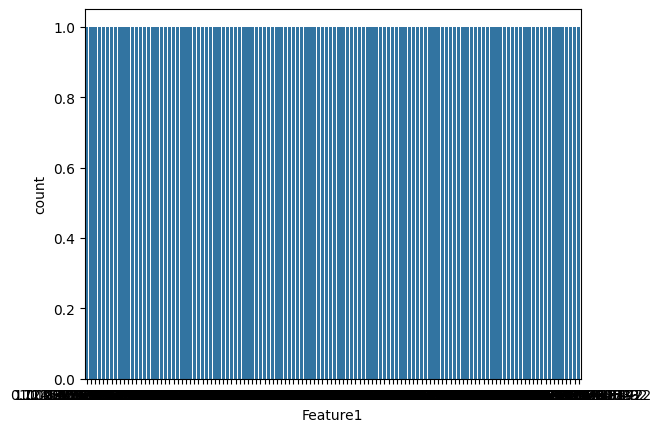

In [ ]:



sns.histplot(df['Feature1'], kde=True)
plt.title("Diabetes")
plt.show()


sns.countplot(x='Feature1', data=df)
plt.show()



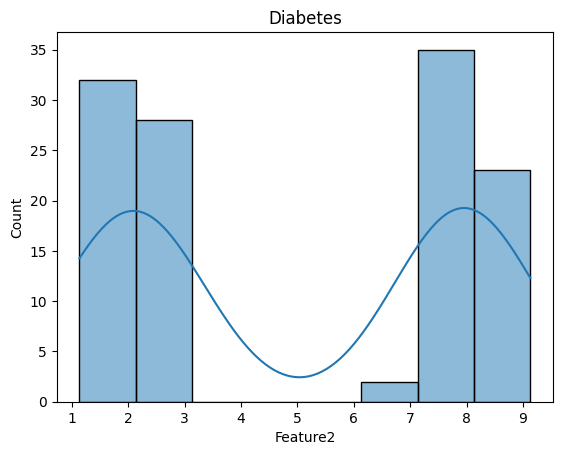

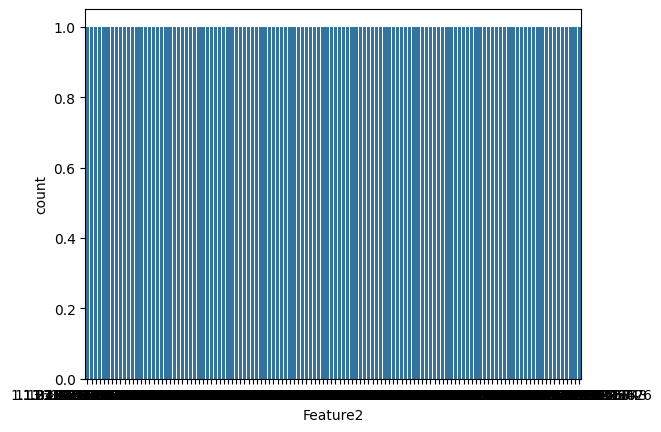

In [ ]:



sns.histplot(df['Feature2'], kde=True)
plt.title("Diabetes")
plt.show()


sns.countplot(x='Feature2', data=df)
plt.show()



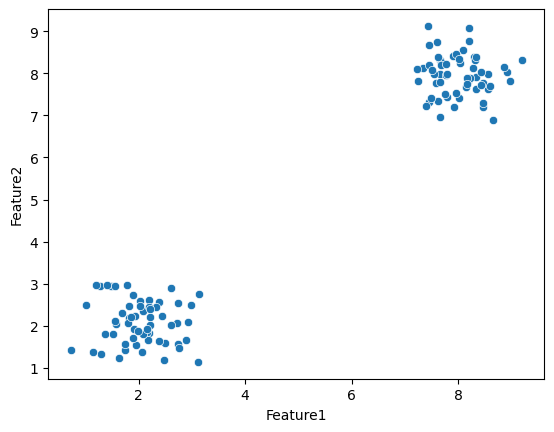

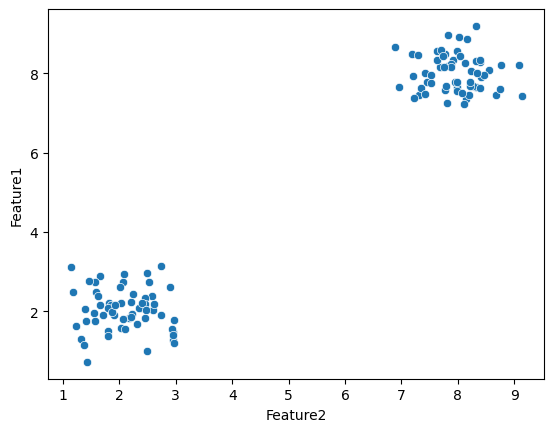

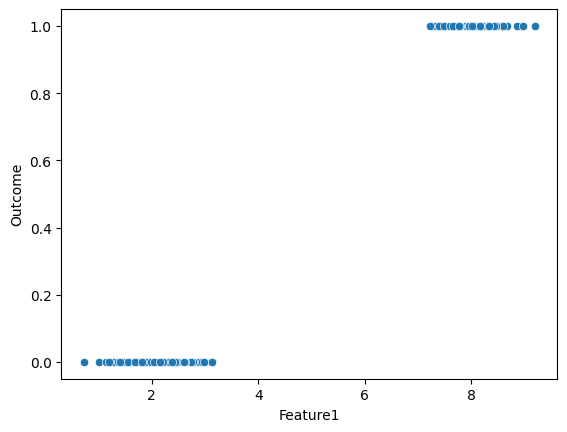

In [ ]:


sns.scatterplot(x='Feature1', y='Feature2', data=df)
plt.show()

sns.scatterplot(x='Feature2', y='Feature1', data=df)
plt.show()

sns.scatterplot(x='Feature1', y='Outcome', data=df)
plt.show()



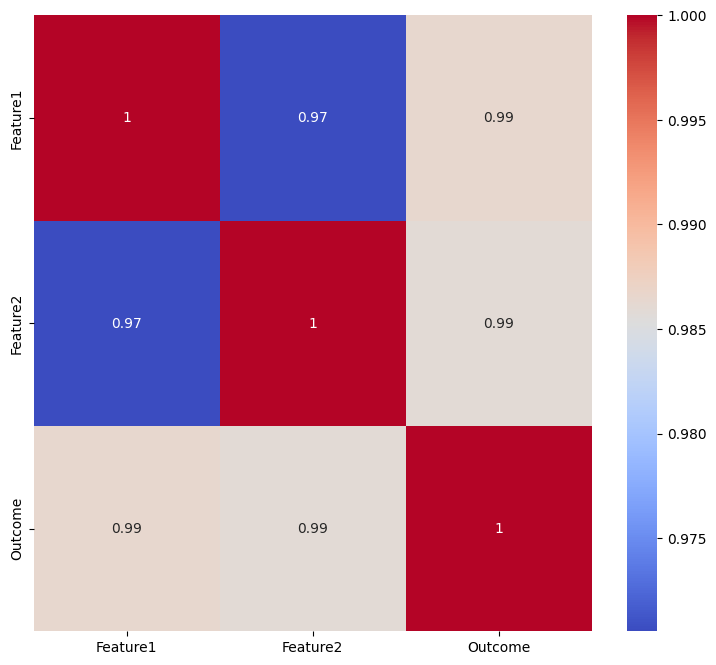

In [ ]:



plt.figure(figsize=(9,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()


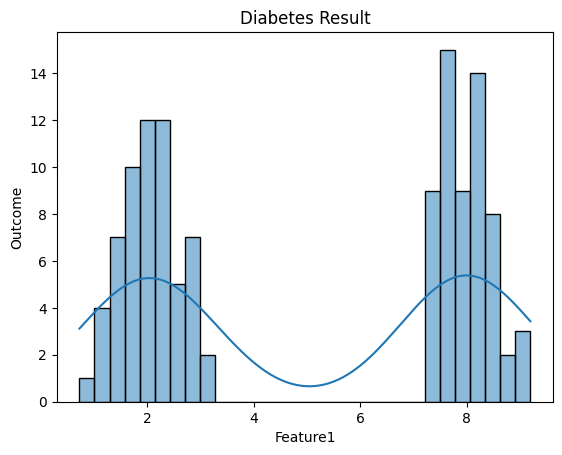

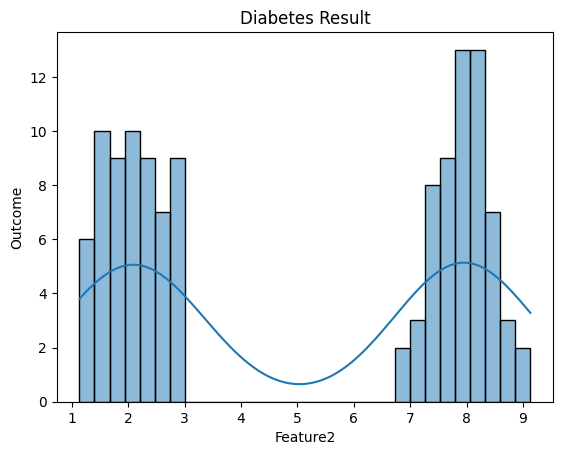

In [ ]:



sns.histplot(df['Feature1'], kde=True, bins=30)
plt.title("Diabetes Result")
plt.xlabel("Feature1")
plt.ylabel("Outcome")
plt.show()

sns.histplot(df['Feature2'], kde=True, bins=30)
plt.title("Diabetes Result")
plt.xlabel("Feature2")
plt.ylabel("Outcome")
plt.show()

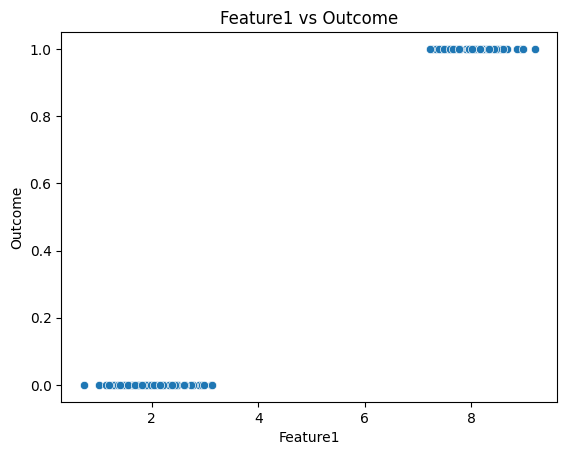

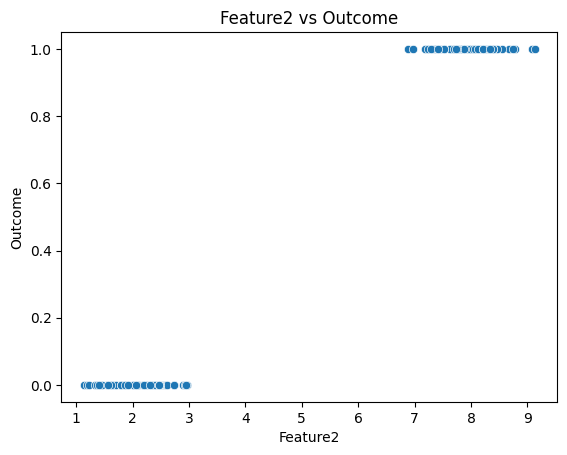

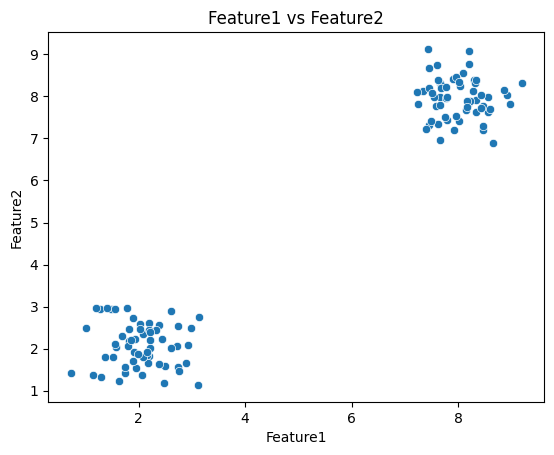

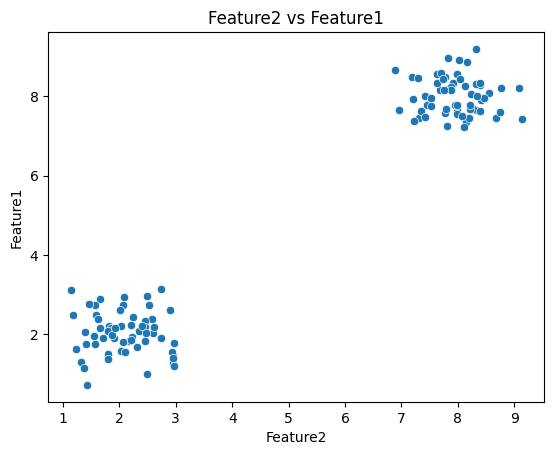

In [ ]:

sns.scatterplot(x='Feature1', y='Outcome', data=df)
plt.title("Feature1 vs Outcome")
plt.show()


sns.scatterplot(x='Feature2', y='Outcome', data=df)
plt.title("Feature2 vs Outcome")
plt.show()




sns.scatterplot(x='Feature1', y='Feature2', data=df)
plt.title("Feature1 vs Feature2")
plt.show()

sns.scatterplot(x='Feature2', y='Feature1', data=df)
plt.title("Feature2 vs Feature1")
plt.show()



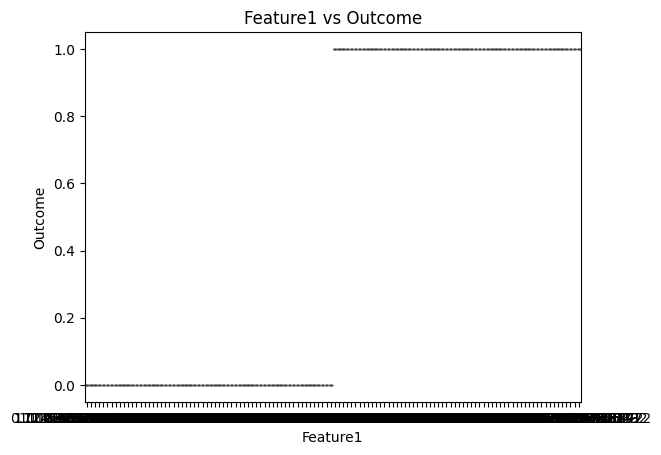

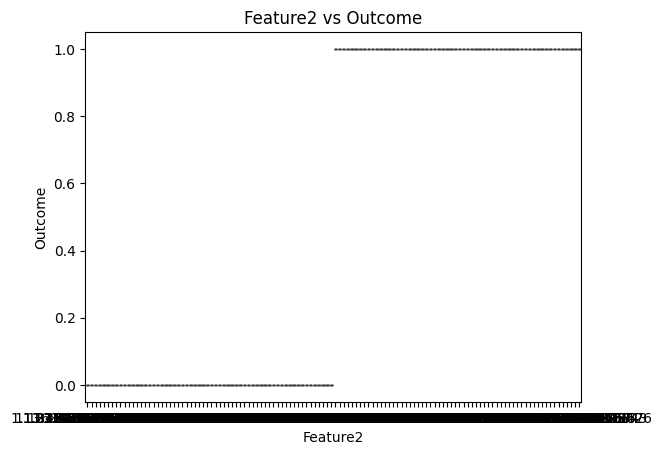

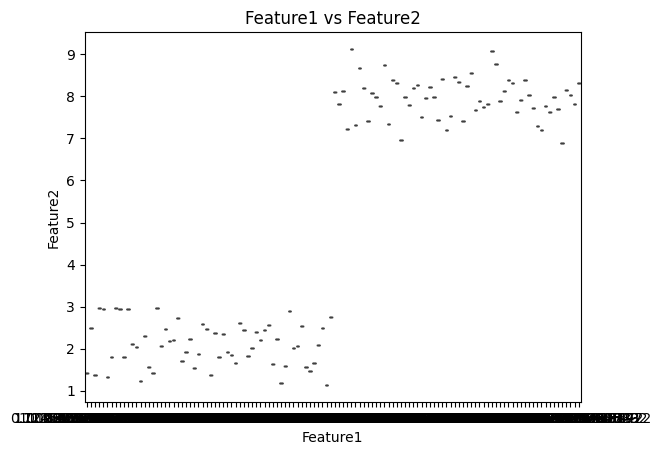

In [ ]:

sns.boxplot(x='Feature1', y='Outcome', data=df)
plt.title("Feature1 vs Outcome")
plt.show()


sns.boxplot(x='Feature2', y='Outcome', data=df)
plt.title("Feature2 vs Outcome")
plt.show()


sns.boxplot(x='Feature1', y='Feature2', data=df)
plt.title("Feature1 vs Feature2")
plt.show()





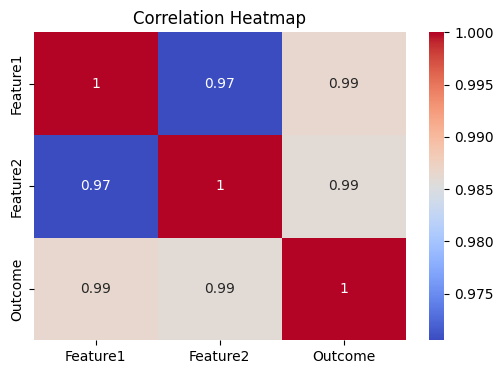

In [ ]:


plt.figure(figsize=(6,4))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


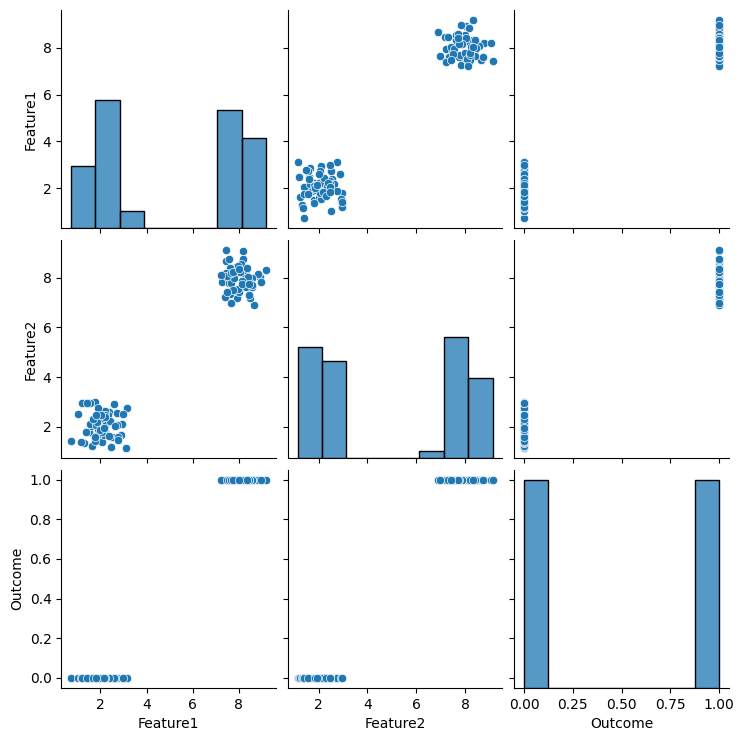

In [ ]:


sns.pairplot(df[[ 'Feature1','Feature2','Outcome' ]])
plt.show()


In [ ]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score



df = pd.read_csv("diabetes.csv")



X = df.drop("Outcome", axis=1)
y = df["Outcome"]



X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)



model = LinearRegression()



model.fit(X_train, y_train)



y_pred = model.predict(X_test)


mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)


print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE : 0.052959901543395714
MSE : 0.0036533658649111358
RMSE: 0.060443079545231114
R2 Score: 0.9852843444881901


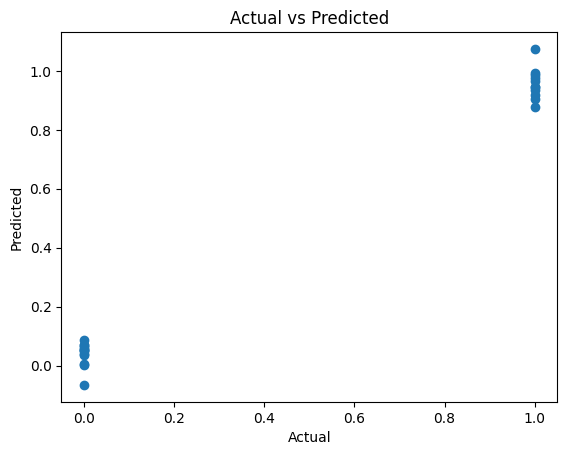

In [ ]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

Accuracy: 1.0

Confusion Matrix:
 [[13  0]
 [ 0 11]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        13
           1       1.00      1.00      1.00        11

    accuracy                           1.00        24
   macro avg       1.00      1.00      1.00        24
weighted avg       1.00      1.00      1.00        24



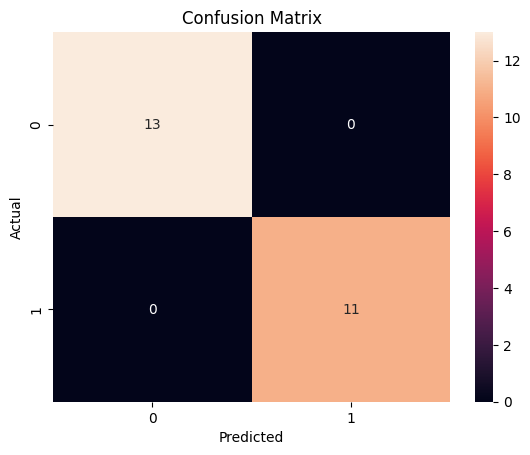

In [ ]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

df = pd.read_csv("diabetes.csv")


X = df.drop("Outcome", axis=1)
y = df["Outcome"]


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


model = LogisticRegression()
model.fit(X_train, y_train)


y_pred = model.predict(X_test)


accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred)


print("Accuracy:",accuracy)
print("\nConfusion Matrix:\n",cm)
print("\nClassification Report:\n", report)



sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:

print(classification_report(y_test, y_pred))

report = pd.DataFrame(classification_report(y_test, y_pred, output_dict=True)).T
print(report)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        13
           1       1.00      1.00      1.00        11

    accuracy                           1.00        24
   macro avg       1.00      1.00      1.00        24
weighted avg       1.00      1.00      1.00        24

              precision  recall  f1-score  support
0                   1.0     1.0       1.0     13.0
1                   1.0     1.0       1.0     11.0
accuracy            1.0     1.0       1.0      1.0
macro avg           1.0     1.0       1.0     24.0
weighted avg        1.0     1.0       1.0     24.0


In [ ]:

print("Accuracy:", accuracy_score(y_test, y_pred))

#
report = pd.DataFrame(classification_report(y_test, y_pred, output_dict=True)).T
print("\nClassification Report Table\n")
print(report)

Accuracy: 1.0

Classification Report Table

              precision  recall  f1-score  support
0                   1.0     1.0       1.0     13.0
1                   1.0     1.0       1.0     11.0
accuracy            1.0     1.0       1.0      1.0
macro avg           1.0     1.0       1.0     24.0
weighted avg        1.0     1.0       1.0     24.0
